In [1]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
import os
import matplotlib.pyplot as plt
import pandas as pd
import math
import pymer4
import numpy as np
from matplotlib.lines import Line2D
import seaborn as sns
import subprocess
from scipy.stats import (ttest_ind, shapiro, levene, mannwhitneyu, 
                         ttest_1samp, wilcoxon)
from pymer4.models import Lmer
import scipy
import pingouin as pg
from matplotlib import lines as mlines


# =============================================================================
# SECTION 2: UTILITY & PLOTTING FUNCTIONS (COMPLETE)
# =============================================================================

def get_repo_root():
    try:
        # This command returns the absolute path of the repository root.
        repo_root = subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"], stderr=subprocess.STDOUT
        ).strip().decode("utf-8")
        return repo_root
    except subprocess.CalledProcessError:
        # If not in a git repository, fall back to current working directory.
        return os.getcwd()

def read_csv_files(directory):
    csv_files = []
    print(f"Checking files in directory: {directory}")
    for filename in os.listdir(directory):
        if filename.startswith("sub") and filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            csv_files.append(df)
    return csv_files

def summarySE(df, measurevar, groupvars, na_rm=True):
    """Compute mean, standard error, and count of observations for each group."""
    # Group by the specified columns
    grouped = df.groupby(groupvars).agg(
        mean=(measurevar, 'mean'),
        count=(measurevar, 'size'),
        std=(measurevar, 'std')
    ).reset_index()
    
    # Calculate standard error
    grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
    
    # Remove rows with NaNs if na_rm is True
    if na_rm:
        grouped = grouped.dropna()
    
    return grouped

def calculate_summary_rel(df, measurevar, groupvar):
    """
    Calculate mean, standard error, and count for a given measure variable.
    """
    summary = df.groupby(groupvar).agg(
        mean=(measurevar, 'mean'),
        count=(measurevar, 'size'),
        std=(measurevar, 'std')
    ).reset_index()
    summary['stderr'] = summary['std'] / np.sqrt(summary['count'])
    return summary

def wilcoxon_summary(x1, x0, name):
    """
    Mann–Whitney U (rank-sum) for two independent groups.
    Prints U, z (normal approximation), p, and rank-biserial correlation (RBC).
    Numbers are printed with three decimals.
    """
    # Drop missing
    x1 = pd.Series(x1).dropna()
    x0 = pd.Series(x0).dropna()
    n1, n2 = len(x1), len(x0)

    if n1 < 1 or n2 < 1:
        print(f"{name:>3} : not enough data (n1={n1}, n2={n2})")
        return None

    # Mann–Whitney U (independent samples)
    res = mannwhitneyu(x1, x0, alternative='two-sided', use_continuity=False)
    U = float(res.statistic)
    p = float(res.pvalue)

    # Normal approximation for U (no tie correction here)
    mu = n1 * n2 / 2.0
    sigma = math.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
    z = (U - mu) / sigma if sigma > 0 else float('nan')

    # Rank-biserial correlation (positive if group x1 tends to be larger)
    rbc = (2 * U) / (n1 * n2) - 1

    print(f"{name:>3} : U = {U:.3f},  z = {z:.3f},  p = {p:.3f},  RBC = {rbc:.3f}")
    return p


def perform_tests(controls, patients, measure_name):
    """Performs assumption checks and runs t-test or Mann-Whitney U."""
    if len(controls) < 3 or len(patients) < 3:
        print(f"Insufficient data for {measure_name}.")
        return None
    shapiro_controls = shapiro(controls)
    shapiro_patients = shapiro(patients)
    print(f'Shapiro-Wilk for Controls {measure_name}: W={shapiro_controls.statistic:.3f}, p={shapiro_controls.pvalue:.3f}')
    print(f'Shapiro-Wilk for Patients {measure_name}: W={shapiro_patients.statistic:.3f}, p={shapiro_patients.pvalue:.3f}')
    
    levene_test = levene(controls, patients)
    print(f"Levene's Test for {measure_name}: F={levene_test.statistic:.3f}, p={levene_test.pvalue:.3f}")
    
    if (shapiro_controls.pvalue > 0.05 and 
        shapiro_patients.pvalue > 0.05 and 
        levene_test.pvalue > 0.05):
        t_stat, p_value = ttest_ind(controls, patients)
        print(f'--> T-test for {measure_name}: t={t_stat:.3f}, p={p_value:.4f}')
    else:
        u_stat, p_value = mannwhitneyu(controls, patients)
        print(f'--> Mann-Whitney for {measure_name}: U={u_stat:.1f}, p={p_value:.4f}')
    return p_value

def fit_lmer_robustly(base_formula, data, family, random_effects_list):
    """
    Tries to fit an Lmer model with a sequence of random effects structures,
    from most complex to simplest, until one converges.
    
    It uses the 'bobyqa' optimizer and increased iterations for better stability.
    """
    for re_formula in random_effects_list:
        full_formula = f"{base_formula} + {re_formula}"
        print(f"    Trying to fit: {full_formula}")
        
        model = Lmer(full_formula, data=data, family=family)
        model.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
        
        all_warning_strings = [str(s) for vec in model.warnings for s in vec]
        warnings_string = " ".join(all_warning_strings)
        converged_successfully = "failed to converge" not in warnings_string and "degenerate Hessian" not in warnings_string

        if converged_successfully:
            print("    Model converged successfully.")
            if "boundary (singular) fit" in warnings_string:
                print("    Note: Model produced a singular fit warning.")
            return model
        else:
            print("    Model failed to converge. Trying a simpler random effects structure...")
            
    print(f"    All specifications for {base_formula} failed to converge.")
    return model

def add_orthopoly(df, base_col, prefix):
    """
    Create sample-orthogonal polynomial regressors for 'base_col':
    - prefix_op1: orthogonal 'linear' component
    - prefix_op2: orthogonal 'quadratic' component
    Orthogonal to each other and to the intercept on the observed x.
    """
    x = df[base_col].astype(float).to_numpy()
    mask = ~np.isnan(x)
    X = np.column_stack([np.ones_like(x[mask]), x[mask], x[mask]**2])
    Q, _ = np.linalg.qr(X)  # orthonormal basis
    op1 = np.full_like(x, np.nan, dtype=float)
    op2 = np.full_like(x, np.nan, dtype=float)
    op1[mask] = Q[:, 1]
    op2[mask] = Q[:, 2]
    df[f'{prefix}_op1'] = op1
    df[f'{prefix}_op2'] = op2
    
def plot_boxplot(df, y_col, p_value, y_label, title=None, 
                        y_lim_lower=None, y_lim_upper=None, y_ticks=None):
    """
    Generates a flexible boxplot that auto-scales the y-axis just enough
    to fit the significance bracket without overlapping the title.
    """
    plt.figure(figsize=(9, 6))
    
    ax = sns.boxplot(x='patientstatus', y=y_col, data=df,
                     palette={0: control_color, 1: ocd_color},
                     hue='patientstatus', legend=False)
                     
    sns.swarmplot(x='patientstatus', y=y_col, data=df,
                  color=dot_color, dodge=True, ax=ax, marker='o', size=5)
    
    min_val, max_val = df[y_col].min(), df[y_col].max()
    data_range = max_val - min_val if max_val > min_val else 1
    final_lower_lim = y_lim_lower if y_lim_lower is not None else min_val - (data_range * 0.1)

    if y_lim_upper is not None:
        final_upper_lim = y_lim_upper
        bracket_y = final_upper_lim - ((final_upper_lim - final_lower_lim) * 0.15)
    else:
        total_top_padding = data_range * 0.20
        final_upper_lim = max_val + total_top_padding
        bracket_y = max_val + (total_top_padding / 2.0)

    ax.set_ylim(final_lower_lim, final_upper_lim)
    
    significance_text = get_significance_text(p_value)
    draw_significance_bracket(ax, 0, 1, bracket_y, significance_text)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Controls', 'Patients'])
    
    if y_ticks is not None:
        ax.set_yticks(y_ticks)

    if title is None:
        title = f'Average {y_label} Comparison'
    ax.set_title(title)

    ax.set_xlabel('Group')
    ax.set_ylabel(f'Average {y_label}')
    plt.tight_layout()
    plt.show()

def remove_outliers_IQR(df, columns, factor=1.5):
    df = df.copy()
    bad_idx = set()
    bounds = {}
    for col in columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - factor*iqr, q3 + factor*iqr
        bounds[col] = (lo, hi)
        bad_idx |= set(df.index[(df[col] < lo) | (df[col] > hi)])
    outliers = df.loc[sorted(bad_idx)]
    df_clean = df.drop(index=outliers.index)
    return df_clean, outliers


def draw_significance_bracket(ax, x1, x2, y, text, height_percent=0.01):
    height = y * height_percent
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], lw=1.5, color='black')
    ax.plot([x1, x1], [y, y - height], lw=1.5, color='black')
    ax.plot([x2, x2], [y, y - height], lw=1.5, color='black')
    font_tmp = 16 if text == 'n.s.' else 18
    ax.text((x1 + x2) * 0.5, y + height * 1.5, text, ha='center', va='bottom', color='black', fontsize=font_tmp)

def get_significance_text(p_value):
    if p_value is None: return ''
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'n.s.'

def plot_accuracy_boxplot_ax(ax, average_data, p_value_acc):
    """Plots just the accuracy boxplot without the main y-label."""
    perc95 = np.percentile(average_data['average_accuracy'], 95)
    ylim = perc95 + 0.1
    sns.boxplot(x='patientstatus', y='average_accuracy', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.5, linewidth=1.5)
    sns.stripplot(x='patientstatus', y='average_accuracy', data=average_data, color=dot_color, jitter=True, ax=ax, marker='o', size=5)
    ax.set_ylim(0.4, ylim)
    significance_text = get_significance_text(p_value_acc)
    draw_significance_bracket(ax, 0, 1, ylim - 0.07, significance_text)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels([])
    ax.set_xlabel('Overall', fontsize=16)
    ax.set_ylabel('') 
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', bottom=False)
    sns.despine(ax=ax)

def plot_confidence_boxplot_ax(ax, average_data, p_value_conf):
    """Plots just the confidence boxplot without the main y-label."""
    sns.boxplot(x='patientstatus', y='average_confidence', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.5, linewidth=1.5, showfliers=False)
    sns.stripplot(x='patientstatus', y='average_confidence', data=average_data, color=dot_color, jitter=True, ax=ax, marker='o', size=5)
    
    ylim = 120
    ax.set_ylim(0, ylim)
    significance_text = get_significance_text(p_value_conf)
    draw_significance_bracket(ax, 0, 1, ylim - 7, significance_text)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels([])
    ax.set_xlabel('Overall', fontsize=16)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', bottom=False)
    sns.despine(ax=ax)

def plot_mean_var_ax(ax, summary_controls, summary_patients, measurevar, ylabel, xlabel, ylim, yticks, colors):
    summary_controls = pd.DataFrame(summary_controls)
    summary_patients = pd.DataFrame(summary_patients)
    summary_controls['patientstatus'] = 'Controls'
    summary_patients['patientstatus'] = 'Patients'
    
    df_combined = pd.concat([summary_controls, summary_patients], ignore_index=True)
    ax.axvline(0, color=dot_color, linewidth=1, linestyle='--')
    for group_key, color in colors.items():
        label = 'Controls' if group_key == 0 else 'Patients'
        subset = df_combined[df_combined['patientstatus'] == label]
        sns.lineplot(data=subset, x='nTrial_rel', y='mean', color=color, ax=ax)
        sns.scatterplot(data=subset, x='nTrial_rel', y='mean', color=color, edgecolor='white', s=100, label=label, ax=ax)
        ax.errorbar(subset['nTrial_rel'], subset['mean'], yerr=subset['stderr'], fmt='none', color=color, capsize=5)
    
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.set_xticks(np.arange(-5, 6, 1))
    
    ax.set_xlabel(xlabel, fontsize=16, fontweight='bold')
    ax.set_ylabel(' ', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax.tick_params(axis='x', labelsize=14, width=1.5, bottom=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    if measurevar == 'mean_accuracy':
        ax.legend(title='Group', fontsize=14, title_fontsize=14, loc='lower left')
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    sns.despine()

def plot_rt_boxplot_ax(ax, average_data, p_value_rt_log):
    perc95 = np.percentile(average_data['average_RT'], 95)
    ylim = perc95 + (perc95 * 0.1)
    sns.boxplot(x='patientstatus', y='average_RT', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.3, linewidth=1.5,showfliers=False)
    sns.stripplot(x='patientstatus', y='average_RT', data=average_data, color=dot_color, jitter=True, ax=ax, marker='o', size=5)
    ax.set_ylim(0, ylim)
    significance_text = get_significance_text(p_value_rt_log)
    draw_significance_bracket(ax, 0, 1, ylim - (ylim * 0.07), significance_text)
    
    ax.set_xticks([0.5])
    ax.set_xticklabels(['Overall'])
    ax.set_yticks(np.linspace(0, ylim, 6))
    ax.set_xlabel(' ')
    ax.set_ylabel('Mean Reaction Time (RT)', fontweight='bold', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='y', left=True, width=1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    sns.despine(ax=ax)

def prettify_term(term):
    # Handle interaction terms
    if ':' in term:
        parts = term.split(':')
        pretty_parts = [rename_map.get(p, p) for p in parts]
        return " ×\n".join(pretty_parts)
    else:
        return rename_map.get(term, term)

def zscore_within(x):
    """Computes the z-score within each group, avoiding division by zero."""
    m = x.mean()
    s = x.std(ddof=1)
    return (x - m) / s if s > 0 else x - m

# Define colors
ocd_color = '#5f8cff'
control_color = '#b4a854'
dot_color ='#57504d'
regressor_color ="#673C33"
custom_palette = {"0": control_color, "1": ocd_color}

In [2]:
# =============================================================================
# SECTION 3: DATA LOADING & PREPROCESSING
# =============================================================================

repo_root = get_repo_root()
print("Repository Root:", repo_root)

# Set the directory path
directory = os.path.join(repo_root, "data")

# Call the function and get the list of dataframes
dataframes = read_csv_files(directory)

# Display the first few rows of each DataFrame
for i, df in enumerate(dataframes):
    print(f"First few rows of DataFrame {i+1}:")
    print(df.head())
    print("\n")

# Set directory to the data folder within the repository.
data_dir = os.path.join(repo_root, "data")
os.chdir(data_dir)
# Load data
CrypticCreatures = pd.read_csv("Table_CrypticCreatures_YaleCohort.csv")
CrypticCreatures.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreature_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_YaleCohort.csv")
CrypticCreatures_patients_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_patients_YaleCohort.csv")
CrypticCreatures_patients_relativeShift = CrypticCreatures_patients_relativeShift.sort_values(by=['id', 'nTrial_rel'])
CrypticCreatures_controls_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_controls_YaleCohort.csv")
CrypticCreatures_controls_relativeShift = CrypticCreatures_controls_relativeShift.sort_values(by=['id', 'nTrial_rel'])

CrypticCreatures_BayesianLearner = pd.read_csv("CrypticCreatures_BayesianLearner.csv")
CrypticCreatures_BayesianLearner = CrypticCreatures_BayesianLearner.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreatures_BayesianLearner_patients_relativeShift = pd.read_csv("CrypticCreaturesBayesianLearner_relativeShift_OCD.csv")
CrypticCreatures_BayesianLearner_patients_relativeShift = CrypticCreatures_BayesianLearner_patients_relativeShift.sort_values(by=['id', 'nTrial_rel'])
CrypticCreatures_BayesianLearner_controls_relativeShift = pd.read_csv("CrypticCreaturesBayesianLearner_relativeShift_controls.csv")
CrypticCreatures_BayesianLearner_controls_relativeShift = CrypticCreatures_BayesianLearner_controls_relativeShift.sort_values(by=['id', 'nTrial_rel'])

Repository Root: /Users/alisaloosen/Documents/GitHub/BayesianObserver_CognitiveFlexibilityOCD
Checking files in directory: /Users/alisaloosen/Documents/GitHub/BayesianObserver_CognitiveFlexibilityOCD/data


In [3]:
# Step 1: Define all the DataFrames and columns to be processed
analysis_tasks = {
    'patients': {
        'CrypticCreatures': {
            'df': CrypticCreatures_patients_relativeShift,
            'measures': [
                'mean_accuracy_id', 'mean_accuracy_ed', 'mean_accuracy',
                'mean_confidence_id', 'mean_confidence_ed', 'mean_confidence'
            ]
        },
        'BayesianLearner': {
            'df': CrypticCreatures_BayesianLearner_patients_relativeShift,
            'measures': [
                'entropy', 'sum_prior_chosen_features', 'BLR_confidence',
                'signed_confidence_deviation', 'signed_prior_deviation'
            ]
        }
    },
    'controls': {
        'CrypticCreatures': {
            'df': CrypticCreatures_controls_relativeShift,
            'measures': [
                'mean_accuracy_id', 'mean_accuracy_ed', 'mean_accuracy',
                'mean_confidence_id', 'mean_confidence_ed', 'mean_confidence',
                'mean_RT_id', 'mean_RT_ed', 'mean_RT',
                'mean_RT_log_id', 'mean_RT_log_ed', 'mean_RT_log'
            ]
        },
        'BayesianLearner': {
            'df': CrypticCreatures_BayesianLearner_controls_relativeShift,
            'measures': [
                'entropy', 'sum_prior_chosen_features', 'BLR_confidence',
                'signed_confidence_deviation', 'signed_prior_deviation'
            ]
        }
    }
}


# Step 2: Create an empty dictionary to store all the results.
summary_results = {}

print("--- Starting Efficient Summary Calculation ---")

# Step 3: Loop through all the tasks defined above.
for group_name, tasks in analysis_tasks.items():
    for task_name, task_details in tasks.items():
        input_df = task_details['df']
        for measure_col in task_details['measures']:
            
            # This logic creates your specific variable names
            # e.g., 'mean_accuracy_id' -> 'Cryptic_mean_acc_ID_patients'
            name_part = measure_col.replace('mean_', '').replace('_id', '_ID').replace('_ed', '_ED')
            name_part = name_part.replace('confidence', 'conf').replace('accuracy', 'acc').replace('entropy', 'entr')
            variable_name = f"Cryptic_mean_{name_part}_{group_name}"
            
            print(f"Processing: {variable_name}")
            
            # Run the summary function and store the result in the dictionary
            summary_results[variable_name] = summarySE(input_df, measure_col, ['nTrial_rel'])

print("--- Finished ---")


--- Starting Efficient Summary Calculation ---
Processing: Cryptic_mean_acc_ID_patients
Processing: Cryptic_mean_acc_ED_patients
Processing: Cryptic_mean_acc_patients
Processing: Cryptic_mean_conf_ID_patients
Processing: Cryptic_mean_conf_ED_patients
Processing: Cryptic_mean_conf_patients
Processing: Cryptic_mean_entr_patients
Processing: Cryptic_mean_sum_prior_chosen_features_patients
Processing: Cryptic_mean_BLR_conf_patients
Processing: Cryptic_mean_signed_conf_deviation_patients
Processing: Cryptic_mean_signed_prior_deviation_patients
Processing: Cryptic_mean_acc_ID_controls
Processing: Cryptic_mean_acc_ED_controls
Processing: Cryptic_mean_acc_controls
Processing: Cryptic_mean_conf_ID_controls
Processing: Cryptic_mean_conf_ED_controls
Processing: Cryptic_mean_conf_controls
Processing: Cryptic_mean_RT_ID_controls
Processing: Cryptic_mean_RT_ED_controls
Processing: Cryptic_mean_RT_controls
Processing: Cryptic_mean_RT_log_ID_controls
Processing: Cryptic_mean_RT_log_ED_controls
Process

In [4]:
# data frames
controls_df = CrypticCreatures_controls_relativeShift 
patients_df = CrypticCreatures_patients_relativeShift

# Merge controls dataset based on 'nTrial_rel' and 'id'
controls_merged_df = pd.merge(
    CrypticCreatures_BayesianLearner_controls_relativeShift,
    controls_df,
    on=['nTrial_rel', 'id'],  # Merge on both nTrial_rel and id
    how='inner'  # Use inner join to ensure matching nTrial_rel and id
)

# Merge patients dataset based on 'nTrial_rel' and 'id'
patients_merged_df = pd.merge(
    CrypticCreatures_BayesianLearner_patients_relativeShift,
    patients_df,
    on=['nTrial_rel', 'id'],  # Merge on both nTrial_rel and id
    how='inner'  # Use inner join to ensure matching nTrial_rel and id
)
# List of measure variables for controls and patients
measure_vars = [
    'change_in_mean_accuracy', 'change_in_mean_accuracy_abs', 
    'change_in_mean_accuracy_ed', 'change_in_mean_accuracy_abs_ed', 
    'change_in_mean_accuracy_id', 'change_in_mean_accuracy_abs_id',
    'change_in_mean_confidence', 'change_in_mean_confidence_abs',
    'change_in_mean_confidence_ed', 'change_in_mean_confidence_abs_ed',
    'change_in_mean_confidence_id', 'change_in_mean_confidence_abs_id',
    'signed_confidence_deviation','signed_prior_deviation','mean_confidence','BLR_confidence',
    'mean_accuracy','mean_RT_log','mean_RT'
    
]

# Calculate summaries for controls and patients
summary_controls_rel = {var: calculate_summary_rel(controls_merged_df, var, 'nTrial_rel') for var in measure_vars}
summary_patients_rel = {var: calculate_summary_rel(patients_merged_df, var, 'nTrial_rel') for var in measure_vars}

# 
summary_controls_accuracy = summary_controls_rel['change_in_mean_accuracy']
summary_patients_accuracy = summary_patients_rel['change_in_mean_accuracy']


In [5]:
##############################################################################
# 1)  Run Wilcoxon tests on main table
##############################################################################

df_unique = CrypticCreatures.drop_duplicates(subset='id', keep='first')   # ←── ADDED

# 3) Run Wilcoxon tests on the unique‐ID table
print("\nWilcoxon rank‐sum tests (one row per id):")

wilcoxon_summary(
    df_unique.loc[df_unique['patientstatus']==1, 'age'],
    df_unique.loc[df_unique['patientstatus']==0, 'age'],
    name='Age'
)  

wilcoxon_summary(
    df_unique.loc[df_unique['patientstatus']==1, 'icar_totalscore'],
    df_unique.loc[df_unique['patientstatus']==0, 'icar_totalscore'],
    name='IQ'
)  


Wilcoxon rank‐sum tests (one row per id):
Age : U = 399.500,  z = -0.327,  p = 0.744,  RBC = -0.050
 IQ : U = 466.500,  z = 0.715,  p = 0.471,  RBC = 0.109


0.4707822324961656

In [6]:
# Compute each individual's overall averages for accuracy, confidence, RT, and RT_log
CrypticCreatures['average_accuracy']   = CrypticCreatures.groupby('id')['chosen_outcome'].transform('mean')
CrypticCreatures['average_confidence']   = CrypticCreatures.groupby('id')['confidence'].transform('mean')
CrypticCreatures['average_RT']           = CrypticCreatures.groupby('id')['RT'].transform('mean')
CrypticCreatures['average_RT_log']       = CrypticCreatures.groupby('id')['RT_log'].transform('mean')

# Build a summary DataFrame with one row per subject
average_data = CrypticCreatures[['id', 'average_accuracy', 'average_confidence', 
                                 'average_RT', 'average_RT_log', 'patientstatus']].drop_duplicates()

# Convert patientstatus to integer and split into groups
average_data['patientstatus'] = average_data['patientstatus'].astype(int)
average_data_pat = average_data[average_data['patientstatus'] == 1]
average_data_con = average_data[average_data['patientstatus'] == 0]

# Remove outliers separately for controls and patients (across all measures)
cols_to_check = ['average_accuracy', 'average_confidence', 'average_RT', 'average_RT_log']
average_data_con_clean, outliers_con = remove_outliers_IQR(average_data_con, cols_to_check)
average_data_pat_clean, outliers_pat = remove_outliers_IQR(average_data_pat, cols_to_check)

# Combine cleaned data for overall analysis
average_data_clean = pd.concat([average_data_con_clean, average_data_pat_clean])

p_value_acc    = perform_tests(average_data_con_clean['average_accuracy'],
                                average_data_pat_clean['average_accuracy'], 'Accuracy')
p_value_conf   = perform_tests(average_data_con_clean['average_confidence'],
                                average_data_pat_clean['average_confidence'], 'Confidence')
p_value_rt     = perform_tests(average_data_con_clean['average_RT'],
                                average_data_pat_clean['average_RT'], 'RT')
p_value_rt_log = perform_tests(average_data_con_clean['average_RT_log'],
                                average_data_pat_clean['average_RT_log'], 'RT_log')

# plot_boxplot(average_data_clean, 'average_accuracy', p_value_acc, 'Accuracy', y_ticks=np.arange(0.5, 0.9, 0.1))
# plot_boxplot(average_data_clean, 'average_confidence', p_value_conf, 'Confidence', y_ticks=np.arange(0, 121, 20))
# plot_boxplot(average_data_clean, 'average_RT', p_value_rt, 'RT')
# plot_boxplot(average_data_clean, 'average_RT_log', p_value_rt_log, 'RT (log)')


Shapiro-Wilk for Controls Accuracy: W=0.991, p=0.997
Shapiro-Wilk for Patients Accuracy: W=0.965, p=0.515
Levene's Test for Accuracy: F=0.645, p=0.426
--> T-test for Accuracy: t=-0.438, p=0.6636
Shapiro-Wilk for Controls Confidence: W=0.982, p=0.927
Shapiro-Wilk for Patients Confidence: W=0.957, p=0.360
Levene's Test for Confidence: F=0.288, p=0.594
--> T-test for Confidence: t=3.427, p=0.0013
Shapiro-Wilk for Controls RT: W=0.971, p=0.682
Shapiro-Wilk for Patients RT: W=0.968, p=0.588
Levene's Test for RT: F=6.146, p=0.017
--> Mann-Whitney for RT: U=154.0, p=0.0036
Shapiro-Wilk for Controls RT_log: W=0.974, p=0.773
Shapiro-Wilk for Patients RT_log: W=0.956, p=0.337
Levene's Test for RT_log: F=0.193, p=0.662
--> T-test for RT_log: t=-2.570, p=0.0134


In [7]:
# ===========
# Repeated Measures ANOVA for Task-Specific Analysis
# ===========
rm_data = CrypticCreatures.groupby(['id','task_id','patientstatus'], observed=True).agg(
    average_accuracy   = ('chosen_outcome', 'mean'),
    average_confidence = ('confidence', 'mean'),
    average_RT         = ('RT', 'mean'),
    average_RT_log     = ('RT_log', 'mean'),
    average_repet_err_ed = ('repet_err_ed', 'mean')
).reset_index()

rm_data['patientstatus'] = rm_data['patientstatus'].astype('category')

measures = {
    'average_accuracy': 'Accuracy',
    'average_confidence': 'Confidence',
    'average_RT': 'RT',
    'average_RT_log': 'RT (log)',
    'average_repet_err_ed': 'Repetitive Error'
}

print("\n========== Repeated Measures ANOVA Results ==========\n")
for measure_col, measure_label in measures.items():
    aov = pg.mixed_anova(dv=measure_col, between='patientstatus', within='task_id',
                         subject='id', data=rm_data)
    print(f"Repeated Measures ANOVA for {measure_label}:")
    print(aov, "\n")

# ===========
# Task-Specific Posthoc Analysis after rmANOVA 
# ===========
# This corrected loop now uses the reliable rm_data DataFrame as its source.
for task in sorted(rm_data['task_id'].unique()):
    print(f"\n===== Analysis for Task ID: {task} =====")
    
    # Step 1: Filter the already-aggregated rm_data for the current task
    average_data_task = rm_data[rm_data['task_id'] == task].copy()

    # Step 2: Prepare data for cleaning by splitting into groups
    average_data_task['patientstatus'] = average_data_task['patientstatus'].astype(int)
    task_con = average_data_task[average_data_task['patientstatus'] == 0]
    task_pat = average_data_task[average_data_task['patientstatus'] == 1]
    
    # Step 3: Perform outlier removal on this reliable data
    cols_to_check_task = list(measures.keys())
    task_con_clean, _ = remove_outliers_IQR(task_con, cols_to_check_task, factor=1.5)
    task_pat_clean, _ = remove_outliers_IQR(task_pat, cols_to_check_task, factor=1.5)
    average_data_task_clean = pd.concat([task_con_clean, task_pat_clean])
    
    # Step 4: Print the descriptive summary statistics
    print(f"\n--- Descriptive Statistics for Task ID: {task} ---")
    for col, label in measures.items():
        mean_con = task_con_clean[col].mean()
        sd_con = task_con_clean[col].std()
        mean_pat = task_pat_clean[col].mean()
        sd_pat = task_pat_clean[col].std()
        print(f"{label}: M_controls={mean_con:.3f}, SD_controls={sd_con:.3f}; M_OCD={mean_pat:.3f}, SD_OCD={sd_pat:.3f}")


========== Repeated Measures ANOVA Results ==========

Repeated Measures ANOVA for Accuracy:
          Source        SS  DF1  DF2        MS           F         p-unc  \
0  patientstatus  0.001611    1   56  0.001611    0.228783  6.342901e-01   
1        task_id  1.643927    2  112  0.821963  185.485254  2.861904e-36   
2    Interaction  0.016986    2  112  0.008493    1.916539  1.519092e-01   

      p-GG-corr       np2       eps sphericity   W-spher   p-spher  
0           NaN  0.004069       NaN        NaN       NaN       NaN  
1  1.419879e-28  0.768102  0.771489      False  0.703806  0.000054  
2           NaN  0.033091       NaN        NaN       NaN       NaN   

Repeated Measures ANOVA for Confidence:
          Source            SS  DF1  DF2           MS          F  \
0  patientstatus   4590.253738    1   56  4590.253738   8.207517   
1        task_id  13057.715963    2  112  6528.857982  95.168082   
2    Interaction    190.215258    2  112    95.107629   1.386339   

          

Summary Stats After Incorrect vs. Correct Trials etc

In [8]:
# --- Part 1: Data Preparation ---
print("--- Preparing data for confidence change analysis ---")

# Sort and compute previous trial outcome and change in confidence
CrypticCreatures = CrypticCreatures.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreatures['prev_outcome'] = CrypticCreatures.groupby('id')['chosen_outcome'].shift(1)
if 'confidence_change' not in CrypticCreatures.columns:
    CrypticCreatures['confidence_change'] = CrypticCreatures.groupby('id')['confidence'].diff()

# Mark trials based on the previous trial's outcome and filter
CrypticCreatures['trial_type'] = np.where(
    CrypticCreatures['prev_outcome'] == 1, 'after_correct',
    np.where(CrypticCreatures['prev_outcome'] == 0, 'after_incorrect', None)
)
df_marked = CrypticCreatures.dropna(subset=['trial_type', 'confidence_change'])

# Aggregate scores and create the pivot table
avg_change = df_marked.groupby(['id', 'trial_type'])['confidence_change'].mean().reset_index()
avg_change_pivot = avg_change.pivot(index='id', columns='trial_type', values='confidence_change').reset_index()

# Merge patient status information and ensure correct type
patient_info = CrypticCreatures.groupby('id')['patientstatus'].first().reset_index()
avg_change_pivot = pd.merge(avg_change_pivot, patient_info, on='id')
avg_change_pivot['patientstatus'] = avg_change_pivot['patientstatus'].astype(str)

# Split into final control and patient DataFrames
controls_pivot = avg_change_pivot[avg_change_pivot['patientstatus'] == '0']
patients_pivot = avg_change_pivot[avg_change_pivot['patientstatus'] == '1']
print(f"Data ready. Found {len(controls_pivot)} controls and {len(patients_pivot)} patients.")

# After Correct Trials
controls_correct_raw = controls_pivot['after_correct'].dropna()
patients_correct_raw = patients_pivot['after_correct'].dropna()

# After Incorrect Trials
controls_incorrect_raw = controls_pivot['after_incorrect'].dropna()
patients_incorrect_raw = patients_pivot['after_incorrect'].dropna()

# --- Cleaned Data (After Outlier Removal) ---check

# After Correct Trials
controls_correct_clean_df, _ = remove_outliers_IQR(pd.DataFrame(controls_correct_raw), ['after_correct'])
patients_correct_clean_df, _ = remove_outliers_IQR(pd.DataFrame(patients_correct_raw), ['after_correct'])
c_correct_clean = controls_correct_clean_df['after_correct']
p_correct_clean = patients_correct_clean_df['after_correct']

# After Incorrect Trials
controls_incorrect_clean_df, _ = remove_outliers_IQR(pd.DataFrame(controls_incorrect_raw), ['after_incorrect'])
patients_incorrect_clean_df, _ = remove_outliers_IQR(pd.DataFrame(patients_incorrect_raw), ['after_incorrect'])
c_incorrect_clean = controls_incorrect_clean_df['after_incorrect']
p_incorrect_clean = patients_incorrect_clean_df['after_incorrect']

# For this script, we will proceed with the raw data.
# To use the cleaned data instead, simply replace the variable names below
# (e.g., p_correct_raw -> p_correct_clean).
p_correct = patients_correct_raw
c_correct = controls_correct_raw
p_incorrect = patients_incorrect_raw
c_incorrect = controls_incorrect_raw

# =============================================================================
# --- 2. Within-Group Comparisons (vs. Zero) ---
# =============================================================================
print("\n" + "="*60)
print("Within-Group Tests: Is the average change different from zero?")
print("="*60)

# --- After Correct Trials ---
print("\n--- After Correct Trials ---")
# OCD (Patients): One-sample t-test (assuming normality)
stat_p_corr, pval_p_corr = ttest_1samp(p_correct, popmean=0)
print(f"OCD: t({len(p_correct)-1}) = {stat_p_corr:.3f}, p = {pval_p_corr:.4f}")

# Controls: Wilcoxon signed-rank test (non-parametric)
stat_c_corr, pval_c_corr = wilcoxon(c_correct, zero_method='pratt')
print(f"Controls (Wilcoxon): W = {stat_c_corr:.1f}, p = {pval_c_corr:.4f}")

# --- After Incorrect Trials ---
print("\n--- After Incorrect Trials ---")
# OCD (Patients): One-sample t-test (assuming normality)
stat_p_incorr, pval_p_incorr = ttest_1samp(p_incorrect, popmean=0)
print(f"OCD: t({len(p_incorrect)-1}) = {stat_p_incorr:.3f}, p = {pval_p_incorr:.4f}")

# Controls: Wilcoxon signed-rank test (non-parametric)
stat_c_incorr, pval_c_incorr = wilcoxon(c_incorrect, zero_method='pratt')
print(f"Controls (Wilcoxon): W = {stat_c_incorr:.1f}, p = {pval_c_incorr:.4f}")

# =============================================================================
# --- 3. Between-Group Comparisons ---
# =============================================================================
print("\n" + "="*60)
print("Between-Group Tests: Is there a difference between OCD and Controls?")
print("="*60)

# The Mann-Whitney U test is the correct non-parametric test for comparing
# two independent groups. Reporting the U statistic and an effect size (RBC)
# is more direct and informative than calculating a Z-score from the p-value.

# --- After Correct Trials ---
mwu_correct = pg.mwu(p_correct, c_correct, alternative='two-sided')
u_val_correct = mwu_correct['U-val'].iloc[0]
p_val_correct = mwu_correct['p-val'].iloc[0]
rbc_correct = mwu_correct['RBC'].iloc[0] # Rank-Biserial Correlation
print(f"After Correct: Mann-Whitney U = {u_val_correct:.1f}, p = {p_val_correct:.4f}, RBC = {rbc_correct:.3f}")

# --- After Incorrect Trials ---
mwu_incorrect = pg.mwu(p_incorrect, c_incorrect, alternative='two-sided')
u_val_incorrect = mwu_incorrect['U-val'].iloc[0]
p_val_incorrect = mwu_incorrect['p-val'].iloc[0]
rbc_incorrect = mwu_incorrect['RBC'].iloc[0] # Rank-Biserial Correlation
print(f"After Incorrect: Mann-Whitney U = {u_val_incorrect:.1f}, p = {p_val_incorrect:.4f}, RBC = {rbc_incorrect:.3f}")

num_tests = 2

# Correct the p-value from the "correct trials" test
p_val_correct_bonferroni = min(1.0, p_val_correct * num_tests) # Cap at 1.0

# Correct the p-value from the "incorrect trials" test
p_val_incorrect_bonferroni = min(1.0, p_val_incorrect * num_tests) # Cap at 1.0

significance_incorrect = p_val_incorrect_bonferroni 
significance_correct = p_val_correct_bonferroni

--- Preparing data for confidence change analysis ---
Data ready. Found 29 controls and 29 patients.

Within-Group Tests: Is the average change different from zero?

--- After Correct Trials ---
OCD: t(28) = 7.093, p = 0.0000
Controls (Wilcoxon): W = 57.0, p = 0.0002

--- After Incorrect Trials ---
OCD: t(28) = -5.184, p = 0.0000
Controls (Wilcoxon): W = 138.0, p = 0.0877

Between-Group Tests: Is there a difference between OCD and Controls?
After Correct: Mann-Whitney U = 598.5, p = 0.0058, RBC = 0.423
After Incorrect: Mann-Whitney U = 239.0, p = 0.0049, RBC = -0.432


Mixed-Effects Models

In [9]:
# ===========================================
# 1. Create the .sc variables
# ===========================================

# Z-score 'confidence' within each participant (id)
CrypticCreatures['confidence.sc'] = CrypticCreatures.groupby('id')['confidence'].transform(zscore_within)

# Z-score participant-level variables across all participants
for col, new_col in [('age', 'age.sc'), ('icar_totalscore', 'total_iq.sc')]:
    if col in CrypticCreatures.columns:
        CrypticCreatures[new_col] = (CrypticCreatures[col] - CrypticCreatures[col].mean()) / CrypticCreatures[col].std(ddof=1)

# ===========================================
# 2. Ensure categorical variables are of type 'category'
# ===========================================
categorical_columns = ['patientstatus', 'chosen_outcome_shift', 'task_id', 'IDs', 'EDs', 'ruleChange']
if 'gender' in CrypticCreatures.columns:
    categorical_columns.append('gender')
for col in categorical_columns:
    CrypticCreatures[col] = CrypticCreatures[col].astype(str).astype('category')

# ===========================================
# 3. Create General Shift Variable
# ===========================================
CrypticCreatures['general_shift'] = (CrypticCreatures['ruleChange'].astype(float) > 0).astype(str).astype('category')

# ===========================================
# 4. Create Shifted Variables (Lagged Values)
# ===========================================
shift_vars = ['confidence.sc', 'confidence_change_abs', 'confidence_change']
for var in shift_vars:
    CrypticCreatures[f'{var}_shift'] = CrypticCreatures.groupby('id')[var].shift(1)
for var in ['IDs','EDs','general_shift']:
    CrypticCreatures[f'{var}_shiftback'] = (
        CrypticCreatures.groupby('id')[var].shift(1).astype('category')
    )

# ===========================================
# Build log & orthogonal polynomial terms
#       (replaces the old "+1 + polyval" block)
# ===========================================

# Use raw centered distances for linear/quadratic; reserve +1 only for log()
for base in ['distance_toShift', 'distance_toED', 'distance_toID']:
    # log term (avoid log(0))
    CrypticCreatures[f'log_{base}'] = np.log(CrypticCreatures[base].astype(float) + 1)
    # orthogonal polynomials on the observed x
    add_orthopoly(CrypticCreatures, base, base)

# Replace the string "nan" with an actual NaN
CrypticCreatures = CrypticCreatures.replace("nan", np.nan)

# Drop rows where chosen_outcome_shift is NaN
CrypticCreatures_accmodel = CrypticCreatures.dropna(subset=['chosen_outcome_shift'])

# Remove any unused categories.
for col in ['patientstatus', 'chosen_outcome_shift', 'task_id'] + (['gender'] if 'gender' in CrypticCreatures.columns else []):
    CrypticCreatures[col] = CrypticCreatures[col].cat.remove_unused_categories()

# Print out the levels to verify.
for col in ['patientstatus', 'chosen_outcome_shift', 'task_id'] + (['gender'] if 'gender' in CrypticCreatures.columns else []):
    print(f"{col} levels:", list(CrypticCreatures[col].cat.categories))

# Create the factors dictionary using the string levels.
factors = {col: list(CrypticCreatures[col].cat.categories) for col in ['patientstatus', 'chosen_outcome_shift', 'task_id']}
if 'gender' in CrypticCreatures.columns:
    factors['gender'] = list(CrypticCreatures['gender'].cat.categories)
print("Factors dictionary:", factors)


patientstatus levels: ['0', '1']
chosen_outcome_shift levels: ['0.0', '1.0']
task_id levels: ['1', '2', '3']
gender levels: ['0', '1', '2']
Factors dictionary: {'patientstatus': ['0', '1'], 'chosen_outcome_shift': ['0.0', '1.0'], 'task_id': ['1', '2', '3'], 'gender': ['0', '1', '2']}


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/2939322397.py:51: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  CrypticCreatures = CrypticCreatures.replace("nan", np.nan)


Accuracy models

In [10]:
modelAccRule = Lmer("chosen_outcome ~ general_shift_shiftback*patientstatus + age.sc + gender + total_iq.sc + task_id + (general_shift_shiftback|id) + (1|task_id)",
             data=CrypticCreatures, family="binomial")
resultAccRule = modelAccRule.fit(old_optimizer=True)
print(f'accuracy model general rule shift:', resultAccRule)

boundary (singular) fit: see help('isSingular') 

**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~general_shift_shiftback*patientstatus+age.sc+gender+total_iq.sc+task_id+(general_shift_shiftback|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -6647.557 	 AIC: 13323.115

Random effects:

                                Name    Var    Std
id                       (Intercept)  0.031  0.177
id       general_shift_shiftbackTrue  0.024  0.154
task_id                  (Intercept)  0.000  0.000

            IV1                          IV2  Corr
id  (Intercept)  general_shift_shiftbackTr

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Confidence models

In [11]:
generalShiftModel = Lmer('confidence ~ general_shift_shiftback*patientstatus + age.sc + gender + total_iq.sc + task_id+(1+general_shift_shiftback | id) + (1 | task_id)', 
                   data=CrypticCreatures, 
                   family='gaussian')
resultGeneralShiftModel = generalShiftModel.fit(old_optimizer=True)
print(resultGeneralShiftModel)

model_confidence_interaction = Lmer('confidence ~ patientstatus*chosen_outcome_shift + age.sc + gender + total_iq.sc +task_id+ (chosen_outcome_shift | id) + (1 | task_id)', 
                      data=CrypticCreatures, 
                      family='gaussian')
resultConfAccModel = model_confidence_interaction.fit(old_optimizer=True)
print(resultConfAccModel)

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~general_shift_shiftback*patientstatus+age.sc+gender+total_iq.sc+task_id+(1+general_shift_shiftback|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -52137.455 	 AIC: 104304.909

Random effects:

                                 Name      Var     Std
id                        (Intercept)  124.198  11.144
id        general_shift_shiftbackTrue   44.765   6.691
task_id                   (Intercept)  737.829  27.163
Residual                               532.882  23.084

            IV1                          IV2   Corr
id  (Intercept)  general_shift_shif

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Models - Distance to Shift (incl. comparison)

In [12]:
# Models - Distance to Shift (incl. comparison)
# ============================

# 1) Define predictors
shift_configs = {
    "General Shift": {
        "linear": "distance_toShift",     # raw centered distance
        "poly1":  "distance_toShift_op1", # orthogonal 'linear'
        "poly2":  "distance_toShift_op2", # orthogonal 'quadratic'
        "log":    "log_distance_toShift"
    },
    "ED Shift": {
        "linear": "distance_toED",
        "poly1":  "distance_toED_op1",
        "poly2":  "distance_toED_op2",
        "log":    "log_distance_toED"
    },
    "ID Shift": {
        "linear": "distance_toID",
        "poly1":  "distance_toID_op1",
        "poly2":  "distance_toID_op2",
        "log":    "log_distance_toID"
    }
}

y_vars = ["chosen_outcome", "RT_log", "confidence"]
all_models = {y: {} for y in y_vars}

# 2) Model fitting loop
for y in y_vars:
    print(f"\nFitting models for Dependent Variable: {y}")
    family_type = "binomial" if y == "chosen_outcome" else "gaussian"

    for shift_name, var_names in shift_configs.items():
        print(f"  - Analyzing predictor: {shift_name}")

        # subset to rows where the linear distance exists (for ED/ID)
        if shift_name == "General Shift":
            current_data = CrypticCreatures
        else:
            current_data = CrypticCreatures.dropna(subset=[var_names['linear']])

        # --- Linear Model (raw distance) ---
        lin = var_names['linear']
        base_formula_lin = f"{y} ~ {lin}"
        random_effects_lin = [
            f"(1 + {lin} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Linear"] = fit_lmer_robustly(
            base_formula_lin, current_data, family_type, random_effects_lin
        )

        # --- Quadratic Model (orthogonal op1/op2) ---
        p1 = var_names['poly1']
        p2 = var_names['poly2']
        base_formula_quad = f"{y} ~ {p1} + {p2}"
        random_effects_quad = [
            f"(1 + {p1} + {p2} | id) + (1 | task_id)",
            f"(1 + {p2} | id) + (1 | task_id)",
            f"(1 + {p1} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Quadratic"] = fit_lmer_robustly(
            base_formula_quad, current_data, family_type, random_effects_quad
        )

        # --- Log Model ---
        lvar = var_names['log']
        base_formula_log = f"{y} ~ {lvar}"
        random_effects_log = [
            f"(1 + {lvar} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Log"] = fit_lmer_robustly(
            base_formula_log, current_data, family_type, random_effects_log
        )

# 3) Model Comparison using BIC
for y in y_vars:
    print(f"\n{'='*62}")
    print(f"==================== Model Comparison for: `{y}` ====================")
    print(f"{'='*62}")

    for shift_name in shift_configs.keys():
        print(f"--- Predictor: {shift_name} (Lower BIC is better) ---")
        model_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]

        results = []
        for name in model_names:
            mdl = all_models[y].get(name, None)
            if mdl is not None and hasattr(mdl, 'BIC'):
                results.append({'Name': name, 'BIC': mdl.BIC})

        if results:
            best_model_info = min(results, key=lambda x: x['BIC'])
            header = f"{'Model':<30} {'BIC':>12}"
            print(header)
            print("-" * len(header))
            for res in results:
                print(f"{res['Name']:<30} {res['BIC']:>12.3f}")
            print(f"\n  >>> Best model for {shift_name}: {best_model_info['Name']}\n")
        else:
            print(f"No converged models found for {shift_name}\n")

# 4) Print Full Summaries of Winning Models
print(f"\n\n{'='*70}")
print("="*20 + " SUMMARIES OF WINNING MODELS " + "="*21)
print(f"{'='*70}\n")

for y in y_vars:
    for shift_name in shift_configs.keys():
        model_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]
        results = []
        for name in model_names:
            mdl = all_models[y].get(name, None)
            if mdl is not None and hasattr(mdl, 'BIC'):
                results.append({'Name': name, 'BIC': mdl.BIC})
        if not results:
            continue

        best_model_info = min(results, key=lambda x: x['BIC'])
        best_model_name = best_model_info['Name']
        winning_model = all_models[y][best_model_name]

        print(f"\n--- WINNING MODEL FOR: {y} ~ {shift_name} ---")
        print(f"    (Model Type: {best_model_name.split(' - ')[-1]})")
        if winning_model is not None:
            print(winning_model.summary())
        else:
            print("    ERROR: Winning model object not found.")



Fitting models for Dependent Variable: chosen_outcome
  - Analyzing predictor: General Shift
    Trying to fit: chosen_outcome ~ distance_toShift + (1 + distance_toShift | id) + (1 | task_id)
boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~distance_toShift+(1+distance_toShift|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -6186.781 	 AIC: 12385.562

Random effects:

                     Name    Var    Std
id            (Intercept)  0.018  0.133
id       distance_toShift  0.008  0.090
task_id       (Intercept)  0.272  0.522

            IV1               IV2  Corr
id  (Intercept)  distance_toShift  -1.0

Fixed effects:

    Model converged successfully.
    Trying to fit: chosen_outcome ~ distance_toShift_op1 + distance_toShift_op2 + (1 + distance_toShift_op1 + distance_toShift_op2 | id) + (1 | task_id)


/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~distance_toShift_op1+distance_toShift_op2+(1+distance_toShift_op1+distance_toShift_op2|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -6127.577 	 AIC: 12275.153

Random effects:

                         Name      Var     Std
id                (Intercept)    0.078   0.279
id       distance_toShift_op1  761.165  27.589
id       distance_toShift_op2  191.712  13.846
task_id           (Intercept)    0.280   0.529

                     IV1                   IV2   Corr
id           (Intercept)  distance_toShift_op1  0.931
id           (Intercept)  distance_toShift_op2 -0.219
id  distance_toShift_op1  distance_toShift_op2  0.154

Fixed effects:

    Model converged successfully.
    Trying to fit: chosen_outcome ~ log_distance_toShift + (1 + log_distance_toShift | id)

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toShift+(1+log_distance_toShift|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -6100.830 	 AIC: 12213.660

Random effects:

                         Name    Var    Std
id                (Intercept)  0.000  0.000
id       log_distance_toShift  0.035  0.187
task_id           (Intercept)  0.286  0.535

            IV1                   IV2 Corr
id  (Intercept)  log_distance_toShift     

Fixed effects:

    Model converged successfully.
  - Analyzing predictor: ED Shift
    Trying to fit: chosen_outcome ~ distance_toED + (1 + distance_toED | id) + (1 | task_id)


...

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~distance_toID+(1+distance_toID|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 5258	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -23649.089 	 AIC: 47312.178

Random effects:

                   Name      Var     Std
id          (Intercept)  204.253  14.292
id        distance_toID    0.874   0.935
task_id     (Intercept)  148.717  12.195
Residual                 447.933  21.164

            IV1            IV2   Corr
id  (Intercept)  distance_toID -0.362

Fixed effects:

    Model converged successfully.
    Trying to fit: confidence ~ distance_toID_op1 + distance_toID_op2 + (1 + distance_toID_op1 + distance_toID_op2 | id) + (1 | task_id)
boundary (singular) fit: see help('isSingular') 



/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~distance_toID_op1+distance_toID_op2+(1+distance_toID_op1+distance_toID_op2|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 5258	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -23639.046 	 AIC: 47300.091

Random effects:

                       Name        Var      Std
id              (Intercept)    177.902   13.338
id        distance_toID_op1  48122.930  219.369
id        distance_toID_op2    305.141   17.468
task_id         (Intercept)    148.825   12.199
Residual                       447.898   21.164

                  IV1                IV2   Corr
id        (Intercept)  distance_toID_op1 -0.036
id        (Intercept)  distance_toID_op2  0.451
id  distance_toID_op1  distance_toID_op2  0.876

Fixed effects:

    Model converged successfully.
    Trying to fit: confidence ~ log_distance_toID + (1 + log_distance_toID | id) + (1 | task_id)
Linear mixed model fit by REML [’lmerMod’]
Fo

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Follow-Up Models (post distance to shift)

In [13]:
# Follow-Up Models (post distance to shift)
# ============================================================
# Refit each BIC-winning (y, shift) model WITH interaction (patientstatus)
# ============================================================

# Ensure patientstatus stays a categorical factor (do NOT coerce to numeric)
if 'patientstatus' not in CrypticCreatures.columns:
    raise ValueError("Column 'patientstatus' is missing from CrypticCreatures.")
CrypticCreatures['patientstatus'] = CrypticCreatures['patientstatus'].astype('category')

interaction_models = {y: {} for y in y_vars}

for y in y_vars:
    print(f"\nAdding group interaction for dependent variable: {y}")
    family_type = "binomial" if y == "chosen_outcome" else "gaussian"

    for shift_name, var_names in shift_configs.items():
        candidate_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]
        results = []
        for nm in candidate_names:
            mdl = all_models.get(y, {}).get(nm, None)
            if (mdl is not None) and hasattr(mdl, "BIC"):
                results.append([nm, mdl.BIC])
        if len(results) == 0:
            print(f"  - {shift_name}: No converged base model to augment; skipping.")
            continue

        # pick the base winner
        best_idx = 0
        for i in range(1, len(results)):
            if results[i][1] < results[best_idx][1]:
                best_idx = i
        best_name = results[best_idx][0]
        best_bic  = results[best_idx][1]
        model_type = best_name.split(" - ")[-1]  # "Linear" | "Quadratic" | "Log"

        lin  = var_names['linear']
        p1   = var_names['poly1']
        p2   = var_names['poly2']
        lvar = var_names['log']

        # Use same data selection convention
        if shift_name == "General Shift":
            current_data = CrypticCreatures.copy()
        else:
            current_data = CrypticCreatures.dropna(subset=[lin]).copy()

        # Build fixed-effect formula with interaction(s)
        if model_type == "Linear":
            fe_rhs = f"{lin} * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {lin} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]
        elif model_type == "Quadratic":
            fe_rhs = f"({p1} + {p2}) * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {p1} + {p2} | id) + (1 | task_id)",
                f"(1 + {p2} | id) + (1 | task_id)",
                f"(1 + {p1} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]
        else:  # "Log"
            fe_rhs = f"{lvar} * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {lvar} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]

        formula = f"{y} ~ {fe_rhs}"

        print(f"  - {shift_name}: base winner = {best_name} (BIC={best_bic:.3f})")
        print(f"    Refit WITH interaction using:  {formula}")

        model_int = fit_lmer_robustly(formula, current_data, family_type, random_effects)
        interaction_models[y][f"{shift_name} - {model_type} * group"] = model_int

        base_model = all_models[y][best_name]
        base_bic_print = base_model.BIC if (base_model is not None and hasattr(base_model, "BIC")) else float("nan")
        int_bic_print  = model_int.BIC   if (model_int  is not None and hasattr(model_int,  "BIC")) else float("nan")
        print(f"    BIC (base) = {base_bic_print:.3f}   |   BIC (with interaction) = {int_bic_print:.3f}")

        if model_int is not None:
            print("    --- Interaction model summary ---")
            try:
                print(model_int.summary())
            except Exception as e:
                print(f"    (Could not print summary: {e})")



Adding group interaction for dependent variable: chosen_outcome
  - General Shift: base winner = General Shift - Log (BIC=12257.745)
    Refit WITH interaction using:  chosen_outcome ~ log_distance_toShift * patientstatus + age.sc + gender + total_iq.sc
    Trying to fit: chosen_outcome ~ log_distance_toShift * patientstatus + age.sc + gender + total_iq.sc + (1 + log_distance_toShift | id) + (1 | task_id)
boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toShift*patientstatus+age.sc+gender+total_iq.sc+(1+log_distance_toShift|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -6097.452 	 AIC: 12218.904

Random effects:

                         Name    Var    Std
id                (Intercept)  0.000  0.000
id       log_distance_toShift  0.038  0.194
task_id           (Intercept)  0.287  0.536

        

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toED*patientstatus+age.sc+gender+total_iq.sc+(1+log_distance_toED|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 6213	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -3662.759 	 AIC: 7349.517

Random effects:

                      Name    Var    Std
id             (Intercept)  0.000  0.000
id       log_distance_toED  0.038  0.195
task_id        (Intercept)  0.228  0.478

            IV1                IV2 Corr
id  (Intercept)  log_distance_toED     

Fixed effects:

    Model converged successfully.
    BIC (base) = 7363.941   |   BIC (with interaction) = 7430.330
    --- Interaction model summary ---
Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toED*patientstatus+age.sc+gender+total_iq.sc+(1+log_distance_toED|id)+(1|task_id)

Family: binomial	 Inferen

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toID*patientstatus+age.sc+gender+total_iq.sc+(1+log_distance_toID|id)+(1|task_id)

Family: binomial	 Inference: parametric

Number of observations: 5258	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -2361.010 	 AIC: 4746.019

Random effects:

                      Name    Var    Std
id             (Intercept)  0.034  0.185
id       log_distance_toID  0.174  0.418
task_id        (Intercept)  0.364  0.603

            IV1                IV2  Corr
id  (Intercept)  log_distance_toID  -1.0

Fixed effects:

    Model converged successfully.
    BIC (base) = 4778.105   |   BIC (with interaction) = 4824.830
    --- Interaction model summary ---
Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: chosen_outcome~log_distance_toID*patientstatus+age.sc+gender+total_iq.sc+(1+log_distance_toID|id)+(1|task_id)

Family: binomial	 Infer

...

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~(distance_toShift_op1+distance_toShift_op2)*patientstatus+age.sc+gender+total_iq.sc+(1+distance_toShift_op1+distance_toShift_op2|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -52281.542 	 AIC: 104599.085

Random effects:

                          Name         Var      Std
id                 (Intercept)     123.650   11.120
id        distance_toShift_op1  100948.932  317.725
id        distance_toShift_op2   30191.020  173.756
task_id            (Intercept)     115.321   10.739
Residual                           520.061   22.805

                     IV1                   IV2   Corr
id           (Intercept)  distance_toShift_op1  0.004
id           (Intercept)  distance_toShift_op2  0.099
id  distance_toShift_op1  distance_toShift_op2  0.830

Fixed effects:

    Model converged successfully.
    BIC (base) = 104742.758   |   BIC 

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Linear mixed model fit by REML [’lmerMod’]
Formula: confidence~(distance_toED_op1+distance_toED_op2)*patientstatus+age.sc+gender+total_iq.sc+(1+distance_toED_op1+distance_toED_op2|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 6213	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -28543.620 	 AIC: 57123.239

Random effects:

                       Name        Var      Std
id              (Intercept)    146.668   12.111
id        distance_toED_op1  72794.616  269.805
id        distance_toED_op2  38931.930  197.312
task_id         (Intercept)    103.259   10.162
Residual                       552.293   23.501

                  IV1                IV2   Corr
id        (Intercept)  distance_toED_op1  0.186
id        (Intercept)  distance_toED_op2 -0.172
id  distance_toED_op1  distance_toED_op2 -0.744

Fixed effects:

    Model converged successfully.
    BIC (base) = 57264.454   |   BIC (with interaction) = 57244.459
    --- Interaction model summar

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


Figures for Main Manuscript & Supplemental Information

/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/16278185.py:259: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='patientstatus', y='average_accuracy', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.5, linewidth=1.5)
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/16278185.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='patientstatus', y='average_confidence', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.5, linewidth=1.5, showfliers=False)
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/1823833873.py:37: UserWarning: The figure layout has changed to tight
  plt.tig

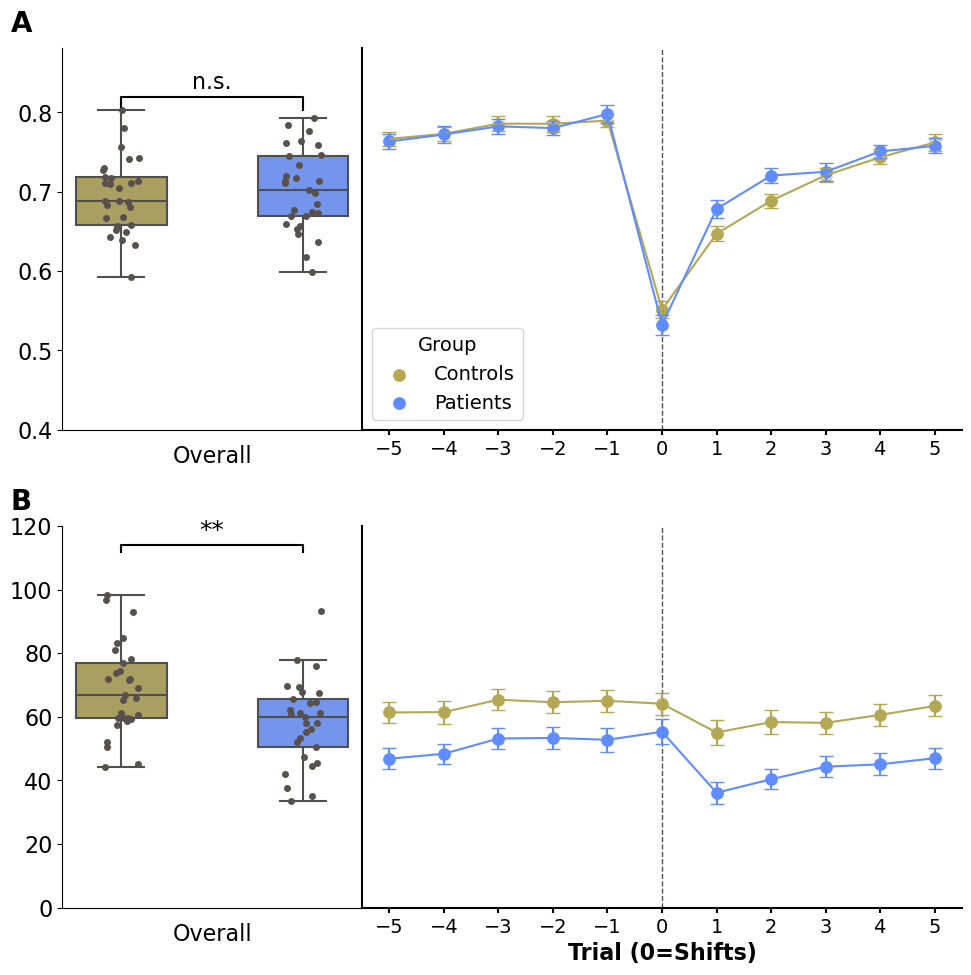

In [14]:
#Figure 2 - Main Manuscript
plt.rcParams.update({'font.size': 16})

# ============
# (2) Create the Combined Figure with 3 Rows
# ============
fig, axes = plt.subplots(
    2, 2, 
    figsize=(10, 10),
    dpi=100,
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 2], 'wspace': 0}
)

# --- Row 0: Accuracy ---
plot_accuracy_boxplot_ax(axes[0, 0], average_data, p_value_acc)
plot_mean_var_ax(axes[0, 1], 
                 summary_controls_rel['mean_accuracy'], 
                 summary_patients_rel['mean_accuracy'], 
                 'mean_accuracy', 'Mean Accuracy', ' ',
                 (0, 1), np.arange(0, 1.1, 0.2), 
                 colors={0: control_color, 1: ocd_color})
axes[0, 0].text(-0.1, 1.1, 'A', transform=axes[0, 0].transAxes, 
                fontsize=20, fontweight='bold', va='top', ha='right')

# --- Row 2: Confidence ---
plot_confidence_boxplot_ax(axes[1, 0], average_data, p_value_conf)
plot_mean_var_ax(axes[1, 1], 
                 summary_controls_rel['mean_confidence'], 
                 summary_patients_rel['mean_confidence'], 
                 'mean_confidence', 'Mean Confidence', 'Trial (0=Shifts)',
                 (20, 115), np.arange(20, 110, 20), 
                 colors={0: control_color, 1: ocd_color})
axes[0, 0].text(-0.1, 1.1, 'B', transform=axes[1, 0].transAxes, 
                fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()

if not os.path.exists('../figures'):
    os.makedirs('../figures')

plt.savefig('../figures/Fig2_AccConf_Average.png', dpi=100)
plt.show()


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/721920889.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/721920889.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/721920889.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axC.set_xticklabels([" ", " "], fontsize=16)
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/721920889.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

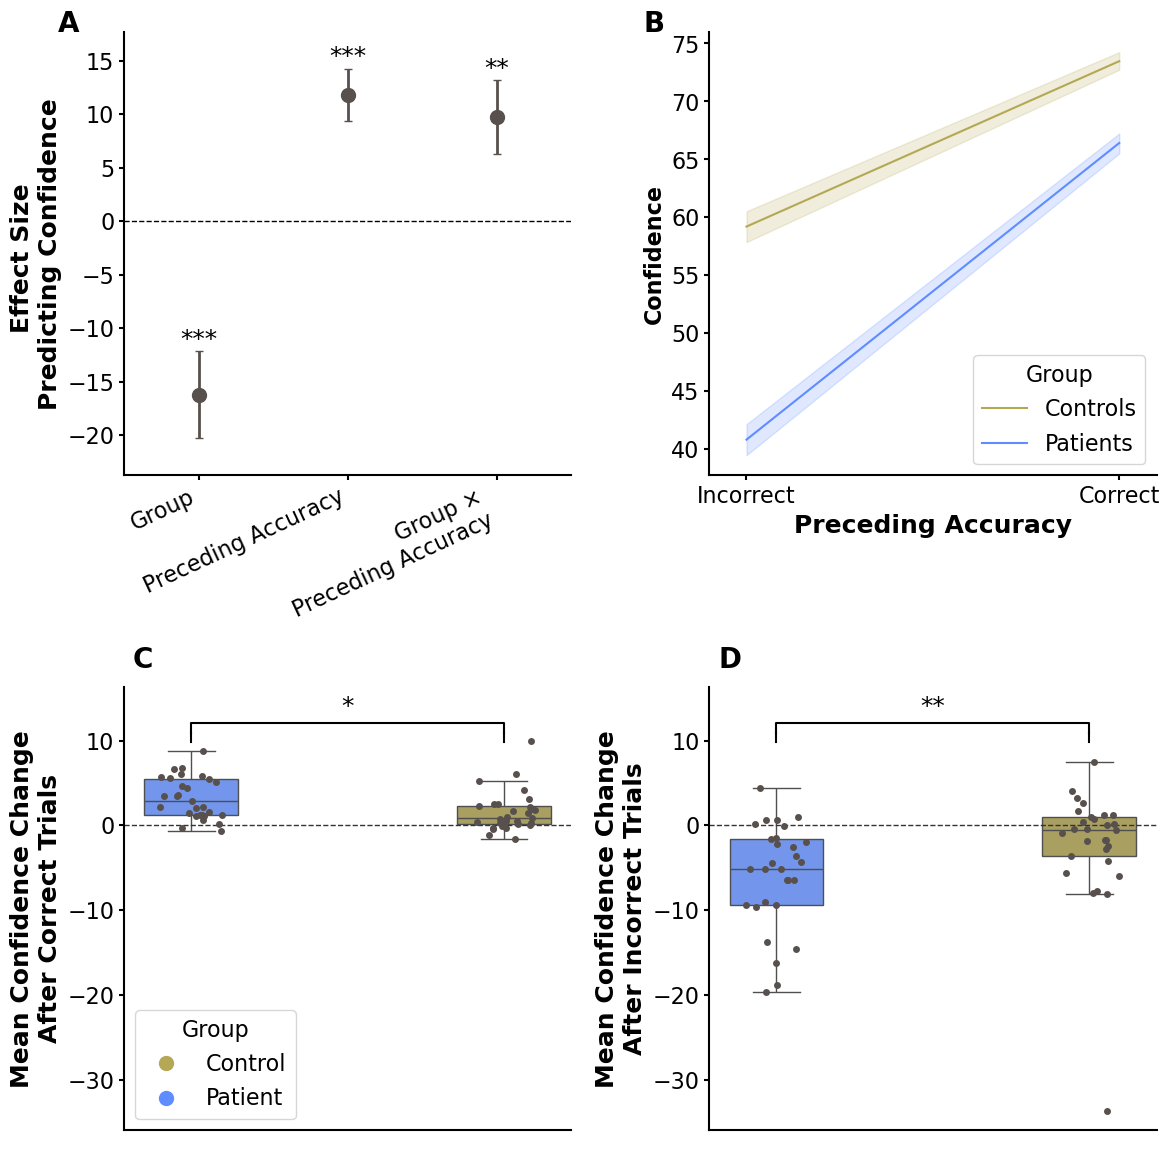

In [15]:
#Figure 3 - Main Manuscript
# -------------------------------
# 0. Sort and create an overall trial variable ("trial_all")
# -------------------------------
sort_cols = ['id']
for col in ['task_id', 'run', 'trial']:
    if col in CrypticCreatures.columns:
        sort_cols.append(col)
CrypticCreatures = CrypticCreatures.sort_values(by=sort_cols)
CrypticCreatures['trial_all'] = CrypticCreatures.groupby('id').cumcount() + 1

# -------------------------------
# 1. Compute previous trial outcome and change in confidence
# -------------------------------
CrypticCreatures['prev_outcome'] = CrypticCreatures.groupby('id')['chosen_outcome'].shift(1)

# -------------------------------
# 2. Mark trials based on the previous trial's outcome
# -------------------------------
# FIX #1: Replaced np.nan with None to avoid the DTypePromotionError.
CrypticCreatures['trial_type'] = np.where(
    CrypticCreatures['prev_outcome'] == 1, 'after_correct',
    np.where(CrypticCreatures['prev_outcome'] == 0, 'after_incorrect', None)
)
df_marked = CrypticCreatures.dropna(subset=['trial_type'])

# -------------------------------
# 3. Aggregate the change scores per participant for each trial type
# -------------------------------
avg_change = (
    df_marked.groupby(['id', 'trial_type'])['confidence_change']
    .mean()
    .reset_index()
)
avg_change_pivot = avg_change.pivot(index='id', columns='trial_type', values='confidence_change').reset_index()
if 'nan' in avg_change_pivot.columns:
    avg_change_pivot = avg_change_pivot.drop('nan', axis=1)

# -------------------------------
# 4. Merge patient status information (assuming one value per participant)
# -------------------------------
patient_info = CrypticCreatures.groupby('id')['patientstatus'].first().reset_index()
avg_change_pivot = pd.merge(avg_change_pivot, patient_info, on='id')

# =============================================================================
# SECOND BLOCK: Regression Coefficients & Pointplot (Panels C and D - Bottom Row)
# =============================================================================
# --- Panel C: Regression Coefficients Plot ---
coefs_confPlot = model_confidence_interaction.coefs.copy()
# Ensure index is string type to avoid dtype promotion errors
coefs_confPlot.index = coefs_confPlot.index.astype(str)
for intercept in ['(Intercept)', 'Intercept']:
    if intercept in coefs_confPlot.index:
        coefs_confPlot = coefs_confPlot.drop(intercept)
demographics = ["age.sc", "gender", "total_iq.sc",'task_id']
pattern = '|'.join(demographics)
coefs_confPlot = coefs_confPlot[~coefs_confPlot.index.str.contains(pattern)]
rename_map = {
    "patientstatus1": "Group",
    "chosen_outcome_shift1.0": "Preceding Accuracy",
    "confidence": "Confidence"
}

coefs_confPlot['Pretty'] = [prettify_term(term) for term in coefs_confPlot.index]

custom_palette = {'0': control_color, '1': ocd_color}
custom_palette_b = {0: control_color, 1: ocd_color}
offset = 0.5  # Adjust this value as needed
x_positions = np.arange(len(coefs_confPlot)) + offset

# =============================================================================
# Create Combined Figure: 2 Rows x 2 Columns with a narrower width
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # Adjusted figsize for a narrower layout
# ----------------------------
# TOP ROW (Panels A & B): Boxplots
# ----------------------------
axA = axes[0, 0]
axA.errorbar(
    x_positions,
    coefs_confPlot['Estimate'],
    yerr=coefs_confPlot['SE'],
    fmt='o',
    color=dot_color,
    ecolor=dot_color,
    elinewidth=2,
    capsize=3,
    markersize=10
)
axA.axhline(0, linestyle='--', color='black', linewidth=1)
axA.set_xticks(x_positions)
axA.set_xticklabels(coefs_confPlot['Pretty'], rotation=25, ha='right', fontsize=16)
axA.set_ylabel('Effect Size \nPredicting Confidence', fontsize=18, fontweight="bold")
axA.set_xlim(0, max(x_positions) + offset)
axA.margins(y=0.1)
axA.spines['top'].set_visible(False)
axA.spines['right'].set_visible(False)
axA.tick_params(axis='y', labelsize=16, width=1.5, left=True)
axA.tick_params(axis='x', labelsize=16, width=1.5, bottom=True)
axA.spines['left'].set_linewidth(1.5)
axA.spines['bottom'].set_linewidth(1.5)
axA.text(-0.1, 1.05, "A", transform=axA.transAxes,
         fontsize=20, fontweight="bold", va="top", ha="right")
for x, (_, row) in zip(x_positions, coefs_confPlot.iterrows()):
    p_val = row['P-val']
    sig = get_significance_text(p_val)
    y = row['Estimate'] + row['SE']
    axA.text(x, y, sig, ha='center', va='bottom', fontsize=18, color='black')

axB = axes[0, 1]
sns.lineplot(
    x="chosen_outcome_shift",
    y="confidence",
    hue="patientstatus",
    data=CrypticCreatures,
    palette=custom_palette,
    ci=95,
    markers=True,
    dashes=False,
    ax=axB
)
axB.spines['top'].set_visible(False)
axB.spines['right'].set_visible(False)
axB.tick_params(axis='y', left=True, width=1.5)
axB.set_xlim(-0.1, 1.1)
axB.set_xlabel("Preceding Accuracy", fontsize=18, fontweight='bold')
axB.set_ylabel("Confidence", fontsize=16, fontweight='bold')
axB.set_xticks([0, 1])
axB.set_xticklabels(["Incorrect", "Correct"], fontsize=14)
axB.tick_params(axis='x', labelsize=16, width=1.5, bottom=True)
axB.spines['left'].set_linewidth(1.5)
axB.spines['bottom'].set_linewidth(1.5)
handles, labels = axB.get_legend_handles_labels()
legend_map = {"0": "Controls", "1": "Patients"}
new_labels = [legend_map.get(label, label) for label in labels]
axB.legend(handles, new_labels, title="Group", loc="lower right", fontsize=16, title_fontsize=16)
axB.text(-0.1, 1.05, "B", transform=axB.transAxes,
         fontsize=20, fontweight="bold", va="top", ha="right")

# ----------------------------
# BOTTOM ROW (Panels C & D): Regression & Pointplot
# ----------------------------

# Ensure patientstatus is string for palette matching
avg_change_pivot['patientstatus'] = avg_change_pivot['patientstatus'].astype(str)

axC = axes[1, 0]
sns.boxplot(
    data=avg_change_pivot,
    x='patientstatus', y='after_correct',
    palette=custom_palette, # Using the now-defined palette
    ax=axC,
    showfliers=False,
    width=0.3
)
sns.stripplot(
    data=avg_change_pivot,
    x='patientstatus', y='after_correct',
    color=dot_color,
    size=5,
    jitter=True,
    ax=axC
)
axC.axhline(y=0, linestyle="--", color="#333333", linewidth=1)
axC.set_xlabel("")
axC.set_ylabel("Mean Confidence Change\nAfter Correct Trials", fontsize=18, fontweight="bold")
axC.set_xticklabels([" ", " "], fontsize=16)
axC.tick_params(axis='y', labelsize=16)
axC.tick_params(axis='x', bottom=False)
axC.tick_params(axis='y', left=True, width=1.5)    
axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)
axC.spines['left'].set_linewidth(1.5)
axC.spines['bottom'].set_linewidth(1.5)
sns.despine(ax=axC)
axC.text(0.02, 1.03, "C", transform=axC.transAxes,
         fontsize=20, fontweight="bold", va="bottom", ha="left")
if significance_correct is not None:
    sig_text = get_significance_text(significance_correct)
    y_max = avg_change_pivot['after_correct'].max() + 1
    draw_significance_bracket(axC, 0, 1, y_max, sig_text, height_percent=0.1)

axD = axes[1, 1]
sns.boxplot(
    data=avg_change_pivot,
    x='patientstatus', y='after_incorrect',
    palette=custom_palette, # Using the now-defined palette
    ax=axD,
    showfliers=False,
    width=0.3
)
sns.stripplot(
    data=avg_change_pivot,
    x='patientstatus', y='after_incorrect',
    color=dot_color,
    size=5,
    jitter=True,
    ax=axD
)
axD.axhline(y=0, linestyle="--", color="#333333", linewidth=1)
axD.set_xlabel("")
axD.set_ylabel("Mean Confidence Change\nAfter Incorrect Trials", fontsize=18, fontweight="bold")
axD.set_xticklabels([" ", " "], fontsize=16)
axD.tick_params(axis='y', labelsize=16)
axD.tick_params(axis='x', bottom=False)
axD.tick_params(axis='y', left=True, width=1.5)
if significance_incorrect is not None:
    sig_textB = get_significance_text(significance_incorrect)
    y_max = avg_change_pivot['after_correct'].max() + 1
    draw_significance_bracket(axD, 0, 1, y_max, sig_textB, height_percent=0.1)
sns.despine(ax=axD)
axD.spines['top'].set_visible(False)
axD.spines['right'].set_visible(False)
axD.spines['left'].set_linewidth(1.5)
axD.spines['bottom'].set_linewidth(1.5)
axD.text(0.02, 1.03, "D", transform=axD.transAxes,
         fontsize=20, fontweight="bold", va="bottom", ha="left")
control_patch = mlines.Line2D([], [], color=control_color, marker="o", linestyle="None", markersize=10, label="Control")
patient_patch = mlines.Line2D([], [], color=ocd_color, marker="o", linestyle="None", markersize=10, label="Patient")
axC.legend(handles=[control_patch, patient_patch], title='Group', fontsize=16, title_fontsize=16, loc='lower left')
common_ylim = [min(axC.get_ylim()[0], axD.get_ylim()[0]),
               max(axC.get_ylim()[1], axD.get_ylim()[1]) + 2]
axC.set_ylim(common_ylim)
axD.set_ylim(common_ylim)
plt.tight_layout()
plt.savefig('../figures/Fig3_Combined_Narrow.png')


Supplemental Information

RT Mixed Models

In [16]:
rtShiftModelGroup = Lmer('RT_log ~ general_shift_shiftback * patientstatus + age.sc + gender + total_iq.sc +task_id+ (general_shift_shiftback | id) + (1 | task_id)', 
                    data=CrypticCreatures, 
                    family='gaussian')
resultRTShiftModelGroup = rtShiftModelGroup.fit(old_optimizer=True)
print(resultRTShiftModelGroup)

**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by REML [’lmerMod’]
Formula: RT_log~general_shift_shiftback*patientstatus+age.sc+gender+total_iq.sc+task_id+(general_shift_shiftback|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -10119.481 	 AIC: 20268.962

Random effects:

                                 Name    Var    Std
id                        (Intercept)  0.077  0.278
id        general_shift_shiftbackTrue  0.010  0.099
task_id                   (Intercept)  0.429  0.655
Residual                               0.337  0.580

            IV1                          IV2   Corr
id  (Intercept)  general_shift_shiftbackTrue  0.056

Fixe

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


In [17]:
model_rt_acc = Lmer('RT_log ~ patientstatus*chosen_outcome_shift + age.sc + gender + total_iq.sc +task_id+ (chosen_outcome_shift | id) + (1 | task_id)', 
                      data=CrypticCreatures, 
                      family='gaussian')
resultRTAccModel = model_rt_acc.fit(old_optimizer=True)
print(resultRTAccModel)

**NOTE**: Column for 'residuals' not created in model.data, but saved in model.resid only. This is because you have rows with NaNs in your data.

**NOTE** Column for 'fits' not created in model.data, but saved in model.fits only. This is because you have rows with NaNs in your data.

Linear mixed model fit by REML [’lmerMod’]
Formula: RT_log~patientstatus*chosen_outcome_shift+age.sc+gender+total_iq.sc+task_id+(chosen_outcome_shift|id)+(1|task_id)

Family: gaussian	 Inference: parametric

Number of observations: 11471	 Groups: {'id': 58.0, 'task_id': 3.0}

Log-likelihood: -9402.568 	 AIC: 18835.137

Random effects:

                             Name    Var    Std
id                    (Intercept)  0.118  0.343
id        chosen_outcome_shift1.0  0.086  0.294
task_id               (Intercept)  0.351  0.592
Residual                           0.298  0.546

            IV1                      IV2   Corr
id  (Intercept)  chosen_outcome_shift1.0 -0.584

Fixed effects:

                       

/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/Users/alisaloosen/miniconda3/envs/bayesian-observer-env/lib/python3.10/site-packages/pymer4/models/Lmer.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_corrs = ran_corrs.applymap(


RT Figure (Supplemental Information)

/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/16278185.py:330: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='patientstatus', y='average_RT', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.3, linewidth=1.5,showfliers=False)
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_17004/1814209198.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


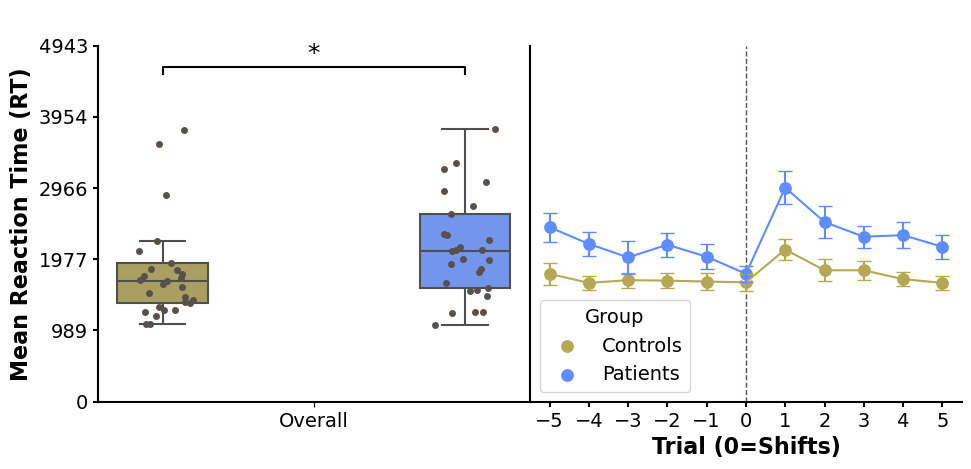

In [18]:
# # --- Supplemental RT Figure---
fig, axes = plt.subplots(
    1, 2,               
    figsize=(10, 5),      
    dpi=100,
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0} 
)

# --- Row 0: RT ---
plot_rt_boxplot_ax(axes[0], average_data, p_value_rt_log)
plot_mean_var_ax(axes[1], 
                 summary_controls_rel['mean_RT'], 
                 summary_patients_rel['mean_RT'], 
                 'mean_RT', 'Mean Reaction Time (RT)', 'Trial (0=Shifts)',
                 (0, 1), np.linspace(0, np.percentile(average_data['average_RT'], 95) * 1.1, 6), 
                 colors={0: control_color, 1: ocd_color})

# --- START: Added Code ---
# Re-add the legend to the second subplot (axes[1]) to match the style of Figure A.
# The plot_mean_var_ax function removes it by default for this variable.
axes[1].legend(title='Group', fontsize=14, title_fontsize=14, loc='lower left')
# --- END: Added Code ---

axes[0].text(-0.1, 1.1, ' ', transform=axes[0].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()

if not os.path.exists('../figures'):
    os.makedirs('../figures')

plt.savefig('../figures/FigS1_RT_Average.png', dpi=100)
plt.show()